# Panel design draft

In [1]:
from pathlib import Path
import sys
import scanpy as sc
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import session_info
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['figure.figsize'] = (4,4)

## Import the reference datasets

In [3]:
base_dir = Path('/home/workspace/private/projects/kim/drg')
panel_dir = base_dir / 'panel/gene-lists'

input_dir = panel_dir / 'output' # this is where the persist output is
output_dir = panel_dir / 'output'
umap_dir = base_dir / 'panel/umap/2025-07-08'
umap_subset_dir = umap_dir / 'subset'

Path(output_dir).mkdir(parents=True, exist_ok=True)
Path(umap_dir).mkdir(parents=True, exist_ok=True)
Path(umap_subset_dir).mkdir(parents=True, exist_ok=True)

In [4]:
adata_path = base_dir / 'data/scrna-seq/h5ad/04_clustered/GSE139088-scvi-leiden.h5ad'
bdata_path = base_dir / 'data/scrna-seq/h5ad/04_clustered/GSE254789-nonneurons.h5ad'

kim_path = panel_dir / 'input/zhen-gene-list_updated.csv' # changed Fam19a1 -> Tafa1, Mrgprc11 -> Mrgprx1 for compatibility with 10x panel design tool
flow_path = panel_dir / 'input/flow-panel-genes.csv'
s1_path = panel_dir / 'output/GSE139088_supervised.csv'
us1_path = panel_dir / 'output/GSE139088_unsupervised.csv'
s2_path = panel_dir / 'output/GSE254789_supervised.csv'
us2_path = panel_dir / 'output/GSE254789_unsupervised.csv'
add_on_path = panel_dir / 'input/2025-07-08_add-on-list.csv' # updated Il6r -> Il6ra

In [5]:
adata = sc.read_h5ad(adata_path)
bdata = sc.read_h5ad(bdata_path)

In [6]:
adata_list = [adata, bdata]

# Rename entries in adata.var
For compatibility with current genome build

In [7]:
adata.var

,mt,ribosomal,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
0610007P14Rik,False,False,6287,1.125146,43.558668,12533.0
0610009B22Rik,False,False,7134,1.895682,35.954754,21116.0
0610009L18Rik,False,False,2742,0.306491,75.383787,3414.0
0610009O20Rik,False,False,1629,0.162851,85.375707,1814.0
0610010F05Rik,False,False,8274,1.754825,25.720442,19547.0
...,...,...,...,...,...,...
Zyg11a,False,False,0,0.000000,100.000000,0.0
Zyg11b,False,False,8463,1.715594,24.023701,19110.0
Zyx,False,False,3661,0.455606,67.133495,5075.0
Zzef1,False,False,6723,1.036538,39.644492,11546.0


In [8]:
# Gene name update mapping
gene_updates = {
    "Fam19a1": "Tafa1",
    "Mrgprc11": "Mrgprx1",
    "Cyr61": "Ccn1",
    "2810417H13Rik": "Pclaf",
    "Fam19a5": "Tafa5",
    "Abcb1": "Abcb1a"
}

# Apply updates and freeze log1p layer into .raw
for ad in adata_list:
    ad.var.rename(index=gene_updates, inplace=True)
    ad.var_names = ad.var.index
    ad.X = ad.layers["log1p"]
    ad.raw = ad.copy()

In [9]:
# Print renamed genes found in .var_names
print([gene for gene in gene_updates.values() if gene in adata.var_names])

# Print original (unrenamed) genes still present
print([gene for gene in gene_updates.keys() if gene in adata.var_names])

['Tafa1', 'Mrgprx1', 'Ccn1', 'Pclaf', 'Tafa5', 'Abcb1a']
[]


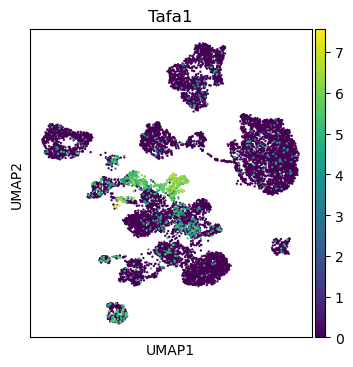

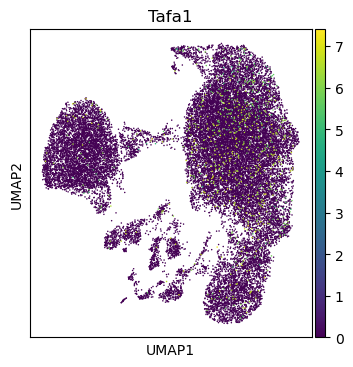

In [10]:
for ad in adata_list:
    sc.pl.umap(ad, color = 'Tafa1')

## Helper functions

In [11]:
def all_genes_in_panel(panel: dict) -> list:
    """
    Returns a set of unique genes from the given panel.
    
    Args:
        panel (dict): A dictionary representing a genomic panel, where keys are sample names and values are lists of gene names for each sample.
    
    Returns:
        set: A set of unique genes found in the given panel.
    """
    return list(set(sum(panel.values(), [])))

def print_panel(panel: dict):
    """
    Prints information about the given panel, including the number of unique genes and a list of genes for each sample.
    
    Args:
        panel (dict): A dictionary representing a genomic panel, where keys are sample names and values are lists of gene names for each sample.
    
    Returns:
        None
    """
    class color:
        PURPLE = '\033[95m'
        CYAN = '\033[96m'
        DARKCYAN = '\033[36m'
        BLUE = '\033[94m'
        GREEN = '\033[92m'
        YELLOW = '\033[93m'
        RED = '\033[91m'
        BOLD = '\033[1m'
        UNDERLINE = '\033[4m'
        END = '\033[0m'

    print(color.UNDERLINE + color.BOLD + "Current Panel" + color.END)
    print(f"currently {color.PURPLE}{len(all_genes_in_panel(panel))}{color.END} unique genes")
    for k in panel.keys():
        import textwrap
        genes = ', '.join(panel[k])
        genes = '\n'.join(textwrap.wrap(genes, 128))
        print(color.BOLD + k + color.END + f" ({len(panel[k])} genes): " + genes)


### Gene lists

In [12]:
# Kim lab gene list
kim_list = pd.read_csv(kim_path)
kim_list = kim_list['gene'].unique()
kim_list = list(kim_list)
print("Kim list length:", len(kim_list), "genes")

# Spectral flow panel genes
flow_list = pd.read_csv(flow_path)
flow_list = flow_list['gene'].unique()
flow_list = list(flow_list)
print("Spectral flow panel list length:", len(flow_list), "genes")

# GSE139088 supervised
s1_list = pd.read_csv(s1_path)
s1_list = s1_list['gene'].unique()
s1_list = list(s1_list)
print("GSE139088 supervised list length:", len(s1_list), "genes")

# GSE139088 unsupervised
us1_list = pd.read_csv(us1_path)
us1_list = us1_list['gene'].unique()
us1_list = list(us1_list)
print("GSE139088 unsupervised list length:", len(us1_list), "genes")

# GSE254789 supervised
s2_list = pd.read_csv(s2_path)
s2_list = s2_list['gene'].unique()
s2_list = list(s2_list)
print("GSE254789 supervised list length:", len(s2_list), "genes")

# GSE254789 unsupervised
us2_list = pd.read_csv(us2_path)
us2_list = us2_list['gene'].unique()
us2_list = list(us2_list)
print("GSE254789 unsupervised list length:", len(us2_list), "genes")

# add-on genes
add_on_list = pd.read_csv(add_on_path)
add_on_list = add_on_list['gene'].unique()
add_on_list = list(add_on_list)
print("Add-on list length:", len(add_on_list), "genes")

Kim list length: 115 genes
Spectral flow panel list length: 51 genes
GSE139088 supervised list length: 50 genes
GSE139088 unsupervised list length: 50 genes
GSE254789 supervised list length: 50 genes
GSE254789 unsupervised list length: 50 genes
Add-on list length: 199 genes


### Putting it together

Part of iterative refinements

In [13]:
panel = {
    "zhen_list": kim_list,
    "spectral_panel": flow_list,
    "GSE139088_supervised": s1_list,
    "GSE139088_unsupervised": us1_list,
    "GSE254789_supervised": s2_list,
    "GSE254789_unsupervised": us2_list,
    "add_on": add_on_list
}

print_panel(panel)

Current Panel
currently 541 unique genes
zhen_list (115 genes): Nppb, Sst, Cysltr1, Cysltr2, Il31ra, Il4ra, Il13ra1, Il13ra2, Osmr, Jak1, Stat6, Piezo2, Adra2a, Bmpr1b, Nefh, Th, Ret, Cd274,
Pdcd1, Kit, Ntrk1, Ntrk2, Ntrk3, Scn8a, Scn9a, Scn10a, Scn11a, Tac1, Calca, Calcb, Nmb, Nts, Adcyap1, Mrgprd, Mrgpra1, Mrgpra3,
Mrgprx1, Mrgprb4, Trpa1, Trpv1, Trpv2, Trpv4, Trpm3, Trpm5, Trpm8, Oprk1, Oprd1, Oprm1, Asic1, Asic2, Asic3, Asic4, P2ry1,
P2ry2, P2ry4, P2rx2, P2rx3, P2rx4, Gfra1, Gfra2, Gfra3, Sstr1, Sstr2, Sstr3, Sstr4, Sstr5, Hrh1, Hrh2, Hrh3, Hrh4, Htr1a, Htr1b,
Htr1d, Htr1f, Htr2a, Htr2b, Htr2c, Htr3a, Htr3b, Htr4, Htr5a, Htr5b, Htr5c, Htr6, Htr7, F2r, F2rl1, F2rl2, F2rl3, S1pr1, S1pr2,
S1pr3, S1pr4, S1pr5, Ptger1, Ptger2, Ptger3, Ptger4, Tnfrsf1a, Il1r1, Il6st, Il17ra, Il10rb, Tlr4, Tlr5, Tlr7, Crlf2, Cbln2,
Ldhb, Necab2, Tafa1, Smr2, Hpse, Spp1, Ntm
spectral_panel (51 genes): Ptprc, Cd8a, Cd44, Thy1, Cd4, Pdcd1, Cd8b1, Ifng, Havcr2, Gzmb, Tnf, Il17a, Prf1, Il2, H2-D1, Foxp3, Rorc,

In [14]:
def are_genes_in_adata(adata, panel: dict):
    """
    Checks if all genes in a panel are present in anndata.

    Parameters:
        adata (anndata.AnnData): The annotated data.
        panel (list or str): The list of gene names or a single string representing the gene name.

    Returns:
        None
    """

    # Let's see if all genes are in the anndata, and if not which are missing
    genes = all_genes_in_panel(panel)
    for gene in genes:
        if gene not in adata.var_names.values:
            print(gene, "not found")

print("drg")
are_genes_in_adata(adata, panel)


drg
Prf1 not found
Cxcr3 not found
Ctla4 not found
Abcb1 not found
Fam19a5 not found
Il17a not found
Il10 not found
Ifng not found
Htr5c not found
Ccr8 not found
Cd19 not found
Cyr61 not found
Cxcr6 not found
Tigit not found
Cd8a not found
Pdcd1 not found
Hrh4 not found
2810417H13Rik not found


## Putting it together

In [15]:
# update panel with renamed genes (not all the csv were updated)
for key, gene_list in panel.items():
    panel[key] = [gene_updates.get(g, g) for g in gene_list]

In [16]:

all_genes = set(gene for genes in panel.values() for gene in genes)
all_categories = list(panel.keys())

gene_source_matrix = pd.DataFrame(index=sorted(all_genes), columns=all_categories)

for category in all_categories:
    gene_source_matrix[category] = gene_source_matrix.index.isin(panel[category])

gene_source_matrix = gene_source_matrix.reset_index().rename(columns={"index": "Gene"})
gene_source_matrix

,Gene,zhen_list,spectral_panel,GSE139088_supervised,GSE139088_unsupervised,GSE254789_supervised,GSE254789_unsupervised,add_on
0,1500009L16Rik,False,False,True,False,False,False,False
1,AY036118,False,False,False,False,False,True,False
2,Abcb1a,False,False,False,False,False,False,True
3,Ache,False,False,False,False,False,False,True
4,Acta2,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...
536,Xist,False,False,False,True,False,False,False
537,Zbtb8os,False,False,False,True,False,False,False
538,Zfp691,False,False,False,True,False,False,False
539,Zswim7,False,False,False,True,False,False,False


In [17]:
gene_source_matrix = gene_source_matrix[['Gene', 'zhen_list', 'spectral_panel', 'GSE139088_supervised', 'GSE139088_unsupervised', 'GSE254789_supervised', 'GSE254789_unsupervised', 'add_on']] #reorder

cols = ['zhen_list', 'spectral_panel', 'GSE139088_supervised', 'GSE254789_supervised', 'GSE254789_unsupervised', 'GSE139088_unsupervised', 'add_on']
gene_source_matrix = gene_source_matrix.sort_values(
    by=cols,
    ascending=[False] * len(cols)
).reset_index(drop=True)

In [18]:
# clean add-on column
# For each row, check if 'add_on' is True and if True appears in any other category column
non_addon_columns = gene_source_matrix.columns.difference(["Gene", "add_on"])

gene_source_matrix["add_on"] = gene_source_matrix.apply(
    lambda row: False if row["add_on"] and any(row[non_addon_columns]) else row["add_on"],
    axis=1
)
gene_source_matrix

,Gene,zhen_list,spectral_panel,GSE139088_supervised,GSE139088_unsupervised,GSE254789_supervised,GSE254789_unsupervised,add_on
0,Pdcd1,True,True,False,False,False,False,False
1,Adra2a,True,False,False,False,False,False,False
2,Il1r1,True,False,False,False,False,False,False
3,Il6st,True,False,False,False,False,False,False
4,Tnfrsf1a,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
536,Tph2,False,False,False,False,False,False,True
537,Trem2,False,False,False,False,False,False,True
538,Tubb3,False,False,False,False,False,False,True
539,Vip,False,False,False,False,False,False,True


In [19]:
# Count True values (i.e., selected genes) in each category column
category_counts = gene_source_matrix.drop(columns="Gene").sum().sort_values(ascending=False)

print(category_counts)

add_on                    178
zhen_list                 115
spectral_panel             51
GSE139088_supervised       50
GSE139088_unsupervised     50
GSE254789_supervised       50
GSE254789_unsupervised     50
dtype: int64


### Drop problematic genes

In [20]:
genes_to_drop = ["AY036118", "Htr5c"]
gene_source_matrix = gene_source_matrix[~gene_source_matrix["Gene"].isin(genes_to_drop)]

# Swap out this supervised gene which isn't a real gene (BAC cloning vector?) with another supervised gene
gene_source_matrix["Gene"] = gene_source_matrix["Gene"].replace("RP23-291B1.2", "Bcl11a") 

In [21]:
bdata.X[:5, :15].toarray()

array([[0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      ],
       [0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 6.523962, 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      ],
       [0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      ],
       [0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      ],
       [0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 4.873819, 0.      ,
        0.      , 0.      , 0.      ]], dtype=float32)

## Calculate gene detection rate

In [22]:
# Check how many duplicates there are
dup_counts = gene_source_matrix["Gene"].value_counts()
duplicates = dup_counts[dup_counts > 1]
print("Duplicate genes after renaming:\n", duplicates)

Duplicate genes after renaming:
 Series([], Name: count, dtype: int64)


In [23]:
# Step 1: Build detection matrix across adata_list
gene_detection_matrix = pd.DataFrame(index=gene_source_matrix["Gene"])

for i, ad in enumerate(adata_list):
    col_name = f"adata_{i}"
    detected_genes = gene_detection_matrix.index.intersection(ad.var_names)
    detection_percent = (ad[:, detected_genes].X > 0).sum(axis=0) / ad.n_obs * 100
    gene_detection_matrix.loc[detected_genes, col_name] = (
        detection_percent.A1 if hasattr(detection_percent, "A1") else detection_percent
    )

# Step 2: Rename columns to match desired names
gene_detection_matrix = gene_detection_matrix.rename(columns={
    "adata_0": "GSE139088_detection_rate",
    "adata_1": "GSE254789_detection_rate"
})

# Step 3: Calculate combined detection rate
gene_detection_matrix["combined_detection_rate"] = gene_detection_matrix[
    ["GSE139088_detection_rate", "GSE254789_detection_rate"]
].mean(axis=1, skipna=True)

# Step 4: Merge into gene_source_matrix
gene_source_matrix = gene_source_matrix.merge(
    gene_detection_matrix,
    how="left",
    left_on="Gene",
    right_index=True
)

In [24]:
gene_source_matrix

,Gene,zhen_list,spectral_panel,GSE139088_supervised,GSE139088_unsupervised,GSE254789_supervised,GSE254789_unsupervised,add_on,GSE139088_detection_rate,GSE254789_detection_rate,combined_detection_rate
0,Pdcd1,True,True,False,False,False,False,False,NaN,0.000000,0.000000
1,Adra2a,True,False,False,False,False,False,False,4.809395,0.646754,2.728075
2,Il1r1,True,False,False,False,False,False,False,6.207475,1.462057,3.834766
3,Il6st,True,False,False,False,False,False,False,80.510765,17.544685,49.027725
4,Tnfrsf1a,True,False,False,False,False,False,False,4.045111,11.574945,7.810028
...,...,...,...,...,...,...,...,...,...,...,...
536,Tph2,False,False,False,False,False,False,True,1.416721,0.027438,0.722080
537,Trem2,False,False,False,False,False,False,True,0.111846,0.580119,0.345983
538,Tubb3,False,False,False,False,False,False,True,98.928139,56.024616,77.476377
539,Vip,False,False,False,False,False,False,True,0.000000,0.003920,0.001960


### Rename genes to mm10 convention after calculating gene detection rate

In [25]:
# Gene renaming map
#gene_updates = {
#    "Fam19a1": "Tafa1",
#    "Mrgprc11": "Mrgprx1",
#    "Il6r": "Il6ra",
#    "Cyr61": "Ccn1",
#    "2810417H13Rik": "Pclaf",
#    "Fam19a5": "Tafa5",
#    "Abcb1": "Abcb1a"
#}

# Apply renaming
#gene_source_matrix["Gene"] = gene_source_matrix["Gene"].replace(gene_updates)

In [26]:
filename = Path(output_dir) / "2025-07-08_drg-draft-panel.csv"
gene_source_matrix.to_csv(filename, index=False)

# Finishing touches

Iterative modifications and backup genes:

In [27]:
gene_source_matrix

,Gene,zhen_list,spectral_panel,GSE139088_supervised,GSE139088_unsupervised,GSE254789_supervised,GSE254789_unsupervised,add_on,GSE139088_detection_rate,GSE254789_detection_rate,combined_detection_rate
0,Pdcd1,True,True,False,False,False,False,False,NaN,0.000000,0.000000
1,Adra2a,True,False,False,False,False,False,False,4.809395,0.646754,2.728075
2,Il1r1,True,False,False,False,False,False,False,6.207475,1.462057,3.834766
3,Il6st,True,False,False,False,False,False,False,80.510765,17.544685,49.027725
4,Tnfrsf1a,True,False,False,False,False,False,False,4.045111,11.574945,7.810028
...,...,...,...,...,...,...,...,...,...,...,...
536,Tph2,False,False,False,False,False,False,True,1.416721,0.027438,0.722080
537,Trem2,False,False,False,False,False,False,True,0.111846,0.580119,0.345983
538,Tubb3,False,False,False,False,False,False,True,98.928139,56.024616,77.476377
539,Vip,False,False,False,False,False,False,True,0.000000,0.003920,0.001960


In [28]:
genes_to_remove = [
    "Calm1", "Rps15a", "Rps20", "Stmn1", "Dad1", "Hsp90b1", "Xist", "N6amt2", "Tmem261",
    "Aimp1", "Bola1", "Bpgm", "Ccdc25", "Coq7", "Csrp1", "Ctnnb1", "Dad1", "Emp3",
    "Fam216a", "Fkbp2", "Gm1673", "Hmgn3", "Idi1", "Lysmd2", "Lysmd4", "Me1", "Ostf1",
    "Pbdc1", "Pet100", "Pou4f1", "Psmg3", "Psph", "Serinc5", "Serpina3n", "Ubald2", "Id3",
    "Glul", "Tecr", "Tjp1", "Pmvk", "Krcc1", "Dbh", "Mcm3", "Rbfox3", "Chat", "Mrps6",
    "Chrna1", "Gria2", "Tgfbi", "Nr2f2", "mt-Nd6" #"Adrb3", "Gabra2", "Il17rd", "Gja5", 

    # Genes removed 7/8

    ## add_on
    "Il10", "Gfap", "Dlg5", "Gabrb3", "Grin1", "Hey1", "Tubb3", "Mpz", "S100b", "Chrna1", "Chrna7", "Chrna10", "Tie1", "Cdh5", "Apoe", "Cd47", "Cd200", "Dmd", "Fabp7", "Junb",
    "Snap25", "Col1a1",

    ## unsupervised neuron fraction --> problematic
    "Adprh", "Gpm6b", "Hsf2", "Insig1", "Kdm6b", "Mrps28", "Nudt2", "Pdcd4", "Pttg1", "Rbm15", "Rpgrip1", "Sf3b5", "Snrpd1", "Tax1bp3", "Timm9", "Zbtb8os", "Zswim7", "Pim1",

    # unsupervised persist on non neuronal fraction (not problematic but redundancy can be trimmed)
    #"Adamts5", "Cald1", "Dhh", "Ednrb", "Fmo1", "Grrp1", "Rhoc", "Sec11c", "Srsf4", "Ube216"
]

# secondary list --> might want to re-run with an additional five genes from below moved up to genes_to_remove
backup_genes_to_remove = [
    "Tie1",
    "Pecam1",
    "Junb",
    "Egr1",
    "Fosb",
    "Cyr61",
    "Nr4a1",
    "Ly6g",
    "P2ry6",
    "Cd80",
    "Cd86",
    #"Gja5",
    #"Il17rd",
    "Cd200",
    #"Gabra2",
    #"Adrb3",
]

In [36]:
# Remove genes
gene_source_matrix_filtered = gene_source_matrix[~gene_source_matrix["Gene"].isin(genes_to_remove)]

# Drop duplicate genes
gene_source_matrix_filtered = gene_source_matrix_filtered.drop_duplicates(subset="Gene", keep="first")

# Count TRUE values in each column
true_counts = gene_source_matrix_filtered.select_dtypes(include=bool).sum()

# Print result
print(true_counts)

zhen_list                 114
spectral_panel             51
GSE139088_supervised       50
GSE139088_unsupervised     19
GSE254789_supervised       47
GSE254789_unsupervised     27
add_on                    146
dtype: int64


In [37]:
gene_source_matrix_filtered

,Gene,zhen_list,spectral_panel,GSE139088_supervised,GSE139088_unsupervised,GSE254789_supervised,GSE254789_unsupervised,add_on,GSE139088_detection_rate,GSE254789_detection_rate,combined_detection_rate
0,Pdcd1,True,True,False,False,False,False,False,NaN,0.000000,0.000000
1,Adra2a,True,False,False,False,False,False,False,4.809395,0.646754,2.728075
2,Il1r1,True,False,False,False,False,False,False,6.207475,1.462057,3.834766
3,Il6st,True,False,False,False,False,False,False,80.510765,17.544685,49.027725
4,Tnfrsf1a,True,False,False,False,False,False,False,4.045111,11.574945,7.810028
...,...,...,...,...,...,...,...,...,...,...,...
535,Tnfrsf11a,False,False,False,False,False,False,True,17.783577,2.132330,9.957954
536,Tph2,False,False,False,False,False,False,True,1.416721,0.027438,0.722080
537,Trem2,False,False,False,False,False,False,True,0.111846,0.580119,0.345983
539,Vip,False,False,False,False,False,False,True,0.000000,0.003920,0.001960


In [31]:
filename = Path(output_dir) / "2025-07-08_drg-draft-panel-filtered.csv"
gene_source_matrix_filtered.to_csv(filename, index=False)

# Export UMAPs
Export umaps of all the genes to help with elimination process

In [32]:
# dataset_labels = ["GSE139088", "GSE254789"]
# datasets = [adata, bdata]  # Ensure these are defined earlier

# # Ensure umap_dir is a Path object
# umap_dir = Path(umap_dir)

# for gene in gene_source_matrix_filtered["Gene"]:
#     if gene in adata.var_names or gene in bdata.var_names:
#         fig, axs = plt.subplots(1, 2, figsize=(6, 4))

#         for dataset, ax, label in zip(datasets, axs, dataset_labels):
#             if gene in dataset.var_names:
#                 sc.pl.umap(
#                     dataset,
#                     color=gene,
#                     ax=ax,
#                     show=False,
#                     title=label
#                 )
#             else:
#                 ax.set_title(f"{label}\n({gene} not detected)")
#                 ax.axis("off")

#         fig.suptitle(gene, fontsize=14, y=1.02)
#         plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#         plt.savefig(umap_dir / f"{gene}.pdf", bbox_inches="tight")
#         plt.close(fig)

create separate folder for problematic gene sources (neuron unsupervised and my custom add on list have too many highly expressed genes it seems).

annotating which column was True from the gene source matrix as part of the file name:

In [33]:
# # Filter genes based on source
# filtered_genes = gene_source_matrix_filtered[
#     (gene_source_matrix_filtered["GSE139088_unsupervised"] == True) |
#     (gene_source_matrix_filtered["add_on"] == True)
# ]["Gene"]

# # Dataset labels and data
# dataset_labels = ["GSE139088", "GSE254789"]
# datasets = [adata, bdata]  # Ensure defined earlier
# umap_dir = Path(umap_subset_dir)

# # Loop through filtered genes
# for gene in filtered_genes:
#     row = gene_source_matrix_filtered[gene_source_matrix_filtered["Gene"] == gene]

#     # Determine source columns that are True
#     sources = []
#     if row["GSE139088_unsupervised"].values[0] == True:
#         sources.append("GSE139088_unsupervised")
#     if row["add_on"].values[0] == True:
#         sources.append("add_on")

#     # Create filename prefix from full column names
#     prefix = "_".join(sources)

#     if gene in adata.var_names or gene in bdata.var_names:
#         fig, axs = plt.subplots(1, 2, figsize=(6, 4))

#         for dataset, ax, label in zip(datasets, axs, dataset_labels):
#             if gene in dataset.var_names:
#                 sc.pl.umap(
#                     dataset,
#                     color=gene,
#                     ax=ax,
#                     show=False,
#                     title=label
#                 )
#             else:
#                 ax.set_title(f"{label}\n({gene} not detected)")
#                 ax.axis("off")

#         fig.suptitle(gene, fontsize=14, y=1.02)
#         plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#         plt.savefig(umap_dir / f"{prefix}__{gene}.pdf", bbox_inches="tight")
#         plt.close(fig)

# Session info

In [34]:
import os
print('active IDE: sc-sq-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-sq-gpu
active conda environment: sc-spatial


In [35]:
#sc.pl.umap(bdata, color = ['Col3a1', 'Apoe', 'Fabp7', 'Mbp', 'Mpz'], frameon = False, ncols = 5)